# LightGBM Stage 1: Wet/Dry Classifier — Spatial 10-Fold CV

Binary classification: predict whether a station is wet (precip ≥ 0.5 mm) on a given day.

**Features**: `x_proj`, `y_proj`, `elevation_m`, `global_wet_frac`, `knn_wet_frac`, `knn_mean_dist_km`  
**Baseline to beat**: XGBoost v3 — AUC=0.9559, Brier=0.0999, F1-wet=0.8726

## 1. Imports

In [1]:
import sys
import warnings
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.neighbors import BallTree
from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score,
    f1_score,
)

warnings.filterwarnings('ignore')

ROOT = Path('../..')
sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)

print(f'Working directory: {Path.cwd()}')
print(f'LightGBM: {lgb.__version__}')

Working directory: /Users/etomengoi/Desktop/precip_interpolation_thesis
LightGBM: 4.6.0


## 2. Config & Data

In [2]:
from thesis.config import Config
from thesis.data.registry import DataRegistry
from thesis.transforms import ProjectionTransform, IndicatorTransform
from thesis.transforms.pipeline import TransformPipeline

cfg = Config()
registry = DataRegistry.from_config(cfg)

print('Loading raw data...')
all_raw = registry.stations.load(cfg.date_start, cfg.date_end)
print(f'  {len(all_raw):,} rows, {all_raw["station_id"].nunique()} stations')

pipeline = TransformPipeline([
    ProjectionTransform(target_crs=cfg.study_area.target_crs),
    IndicatorTransform(threshold_mm=cfg.wet_day_threshold_mm),
])
all_proc = pipeline.fit_transform(all_raw)

print(f'Processed: {all_proc.shape}')
print(f'Class balance: wet={all_proc["rain_indicator"].mean():.3f}')

Loading raw data...
  45,237,660 rows, 1966 stations
Processed: (45237660, 9)
Class balance: wet=0.385


## 3. Feature Setup

Same features as XGBoost baseline. Computed per-fold to avoid data leakage:
- `global_wet_frac` — fraction of *training* stations that are wet on that day
- `knn_wet_frac` — mean wet indicator among K nearest *training* neighbours
- `knn_mean_dist_km` — mean distance to those K neighbours

In [3]:
df = all_proc.copy()

TARGET_COL = 'rain_indicator'
BASE_FEATS = ['x_proj', 'y_proj', 'elevation_m']

mask_valid = df[BASE_FEATS].notna().all(axis=1)
df_clean = df[mask_valid].copy()

print(f'df_clean: {df_clean.shape}')
print(f'Dropped (NaN): {(~mask_valid).sum():,}')

df_clean: (45237660, 9)
Dropped (NaN): 0


## 4. 5-Fold CV (random station split)

Stations randomly shuffled and split into 5 folds. Each fold holds out ~20% of stations.

In [4]:
K_FOLDS = 5
RANDOM_SEED = 42

station_ids = df_clean['station_id'].unique()
rng = np.random.default_rng(RANDOM_SEED)
shuffled = rng.permutation(station_ids)

fold_assignments = {sid: i % K_FOLDS for i, sid in enumerate(shuffled)}
df_clean['fold'] = df_clean['station_id'].map(fold_assignments)

print('Stations per fold:')
print(df_clean.drop_duplicates('station_id')['fold'].value_counts().sort_index().to_string())

Stations per fold:
fold
0    394
1    393
2    393
3    393
4    393


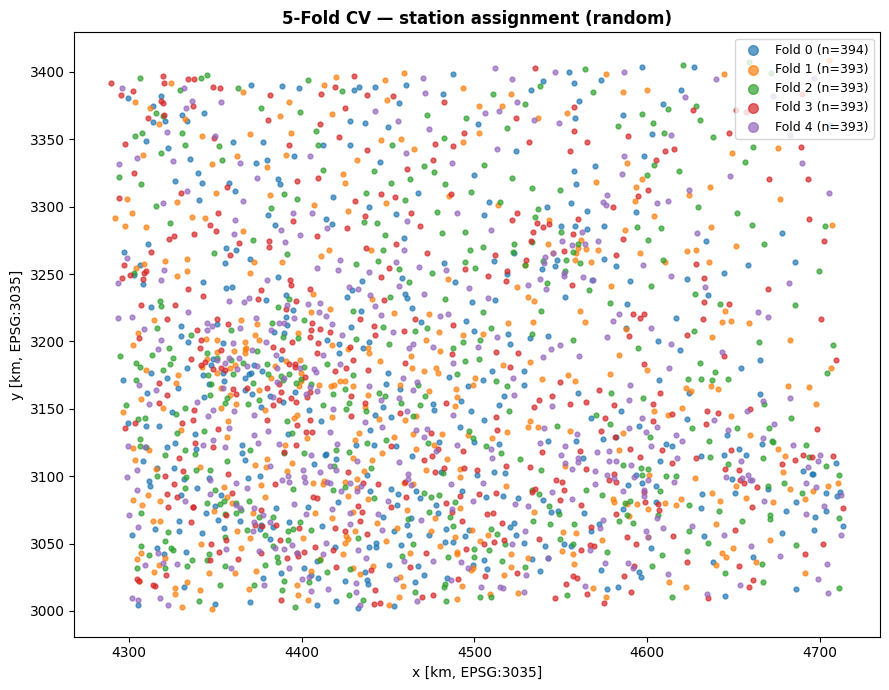

In [5]:
station_meta = df_clean.drop_duplicates('station_id')[['station_id', 'x_proj', 'y_proj', 'fold']].reset_index(drop=True)

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

fig, ax = plt.subplots(figsize=(9, 7))
for fold_id in range(K_FOLDS):
    mask = station_meta['fold'] == fold_id
    ax.scatter(
        station_meta.loc[mask, 'x_proj'] / 1000,
        station_meta.loc[mask, 'y_proj'] / 1000,
        c=colors[fold_id], label=f'Fold {fold_id} (n={mask.sum()})',
        s=12, alpha=0.7,
    )

ax.set_xlabel('x [km, EPSG:3035]')
ax.set_ylabel('y [km, EPSG:3035]')
ax.set_title('5-Fold CV — station assignment (random)', fontweight='bold')
ax.legend(markerscale=2, fontsize=9)
fig.tight_layout()
plt.show()

## 5. Pivot Table

Built once, reused across folds.

In [6]:
print('Building full pivot (date × station_id → rain_indicator)...')
full_pivot = (
    df_clean[['date', 'station_id', 'rain_indicator']]
    .pivot_table(index='date', columns='station_id', values='rain_indicator', aggfunc='first')
)
print(f'Pivot shape: {full_pivot.shape}')

Building full pivot (date × station_id → rain_indicator)...
Pivot shape: (23010, 1966)


## 6. Feature Computation Helper

Identical to XGBoost version — leakage-free per-fold feature computation.

In [7]:
K_NEIGHBORS = 50


def compute_fold_features(df_clean, fold_id, full_pivot, k=K_NEIGHBORS):
    train_mask = df_clean['fold'] != fold_id

    train_meta = (
        df_clean[train_mask]
        .drop_duplicates('station_id')[['station_id', 'x_proj', 'y_proj']]
        .reset_index(drop=True)
    )
    all_meta = (
        df_clean
        .drop_duplicates('station_id')[['station_id', 'x_proj', 'y_proj', 'fold']]
        .reset_index(drop=True)
    )

    train_sids = set(train_meta['station_id'])
    train_sid_to_idx = {sid: i for i, sid in enumerate(train_meta['station_id'])}

    pivot_train = full_pivot[[c for c in full_pivot.columns if c in train_sids]]
    gwf = pivot_train.mean(axis=1)

    tree = BallTree(train_meta[['x_proj', 'y_proj']].values, metric='euclidean')

    tr_dists, tr_idxs = tree.query(train_meta[['x_proj', 'y_proj']].values, k=k + 1)
    all_dists, all_idxs = tree.query(all_meta[['x_proj', 'y_proj']].values, k=k)

    n_all   = len(all_meta)
    n_dates = len(pivot_train)
    wet_mat = np.zeros((n_all, n_dates), dtype=np.float32)
    dist_km = np.zeros(n_all, dtype=np.float32)

    for i in range(n_all):
        sid = all_meta.loc[i, 'station_id']
        if sid in train_sid_to_idx:
            tr_i      = train_sid_to_idx[sid]
            mask_self = tr_dists[tr_i] > 1.0
            nbr_ids   = train_meta['station_id'].values[tr_idxs[tr_i][mask_self]][:k]
            nbr_d     = tr_dists[tr_i][mask_self][:k]
        else:
            nbr_ids = train_meta['station_id'].values[all_idxs[i]]
            nbr_d   = all_dists[i]

        valid_cols = [s for s in nbr_ids if s in pivot_train.columns]
        if valid_cols:
            wet_mat[i] = pivot_train[valid_cols].mean(axis=1).values
        dist_km[i] = nbr_d.mean() / 1000

    knn_wet_df = (
        pd.DataFrame(wet_mat.T, index=pivot_train.index, columns=all_meta['station_id'].values)
        .reset_index()
        .melt(id_vars='date', var_name='station_id', value_name='knn_wet_frac')
    )
    dist_df  = pd.DataFrame({'station_id': all_meta['station_id'].values, 'knn_mean_dist_km': dist_km})
    gwf_df   = gwf.reset_index()
    gwf_df.columns = ['date', 'global_wet_frac']

    df_feat = (
        df_clean
        .merge(gwf_df,     on='date',                 how='left')
        .merge(knn_wet_df, on=['date', 'station_id'], how='left')
        .merge(dist_df,    on='station_id',            how='left')
    )
    return df_feat


FEATURE_COLS = ['x_proj', 'y_proj', 'elevation_m', 'global_wet_frac', 'knn_wet_frac', 'knn_mean_dist_km']
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Features (6): ['x_proj', 'y_proj', 'elevation_m', 'global_wet_frac', 'knn_wet_frac', 'knn_mean_dist_km']


## 7. LightGBM Parameters

Tune here. Key knobs:
- `num_leaves` — model complexity (default 31, try 63/127)
- `min_child_samples` — min samples per leaf (controls overfitting)
- `learning_rate` + `n_estimators` — trade-off speed vs accuracy
- `scale_pos_weight` — class imbalance correction (computed per fold)

In [8]:
THRESHOLD = 0.50  # probability threshold for wet/dry decision

LGB_PARAMS = dict(
    objective          = 'binary',
    metric             = 'auc',
    n_estimators       = 1000,
    learning_rate      = 0.05,
    num_leaves         = 63,
    min_child_samples  = 50,
    feature_fraction   = 0.8,
    bagging_fraction   = 0.8,
    bagging_freq       = 1,
    verbosity          = -1,
    random_state       = 42,
    n_jobs             = -1,
)

## 8. 5-Fold CV Loop

In [9]:
cv_results = []

for fold_id in range(K_FOLDS):
    print(f'\n=== Fold {fold_id} / {K_FOLDS - 1} ===')

    print('  Computing features...')
    df_feat = compute_fold_features(df_clean, fold_id, full_pivot, k=K_NEIGHBORS)

    train_mask = df_feat['fold'] != fold_id
    test_mask  = df_feat['fold'] == fold_id

    X_train = df_feat.loc[train_mask, FEATURE_COLS].values.astype(np.float32)
    y_train = df_feat.loc[train_mask, TARGET_COL].values.astype(np.int32)
    X_test  = df_feat.loc[test_mask,  FEATURE_COLS].values.astype(np.float32)
    y_test  = df_feat.loc[test_mask,  TARGET_COL].values.astype(np.int32)

    n_train = df_feat.loc[train_mask, 'station_id'].nunique()
    n_test  = df_feat.loc[test_mask,  'station_id'].nunique()
    print(f'  Train: {X_train.shape} ({n_train} stations) | Test: {X_test.shape} ({n_test} stations)')

    # class imbalance: computed per fold
    spw = (y_train == 0).sum() / (y_train == 1).sum()

    print('  Training LightGBM...')
    model = LGBMClassifier(**LGB_PARAMS, scale_pos_weight=spw)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)],
    )

    p_wet = model.predict_proba(X_test)[:, 1]

    auc    = roc_auc_score(y_test, p_wet)
    brier  = brier_score_loss(y_test, p_wet)
    f1_wet = f1_score(y_test, p_wet > THRESHOLD)
    f1_dry = f1_score(y_test, p_wet > THRESHOLD, pos_label=0)
    acc    = ((p_wet > THRESHOLD) == y_test).mean()

    print(f'  best_iter={model.best_iteration_}  AUC={auc:.4f}  Brier={brier:.4f}  '
          f'F1-wet={f1_wet:.4f}  F1-dry={f1_dry:.4f}')

    cv_results.append({
        'fold':            fold_id,
        'n_test_stations': n_test,
        'best_iteration':  model.best_iteration_,
        'auc':             auc,
        'brier':           brier,
        'f1_wet':          f1_wet,
        'f1_dry':          f1_dry,
        'accuracy':        acc,
    })

print('\nCV complete.')


=== Fold 0 / 4 ===
  Computing features...
  Train: (36171720, 6) (1572 stations) | Test: (9065940, 6) (394 stations)
  Training LightGBM...
  best_iter=225  AUC=0.9790  Brier=0.0542  F1-wet=0.9078  F1-dry=0.9390

=== Fold 1 / 4 ===
  Computing features...
  Train: (36194730, 6) (1573 stations) | Test: (9042930, 6) (393 stations)
  Training LightGBM...
  best_iter=325  AUC=0.9799  Brier=0.0540  F1-wet=0.9070  F1-dry=0.9394

=== Fold 2 / 4 ===
  Computing features...
  Train: (36194730, 6) (1573 stations) | Test: (9042930, 6) (393 stations)
  Training LightGBM...
  best_iter=332  AUC=0.9808  Brier=0.0530  F1-wet=0.9095  F1-dry=0.9403

=== Fold 3 / 4 ===
  Computing features...
  Train: (36194730, 6) (1573 stations) | Test: (9042930, 6) (393 stations)
  Training LightGBM...
  best_iter=464  AUC=0.9803  Brier=0.0533  F1-wet=0.9080  F1-dry=0.9402

=== Fold 4 / 4 ===
  Computing features...
  Train: (36194730, 6) (1573 stations) | Test: (9042930, 6) (393 stations)
  Training LightGBM...
  

## 9. Results

In [10]:
results_df = pd.DataFrame(cv_results).set_index('fold')

summary = results_df[['auc', 'brier', 'f1_wet', 'f1_dry', 'accuracy']].agg(['mean', 'std'])

print('=== 5-Fold CV Results ===')
print(results_df[['auc', 'brier', 'f1_wet', 'f1_dry', 'accuracy']].round(4).to_string())
print()
print('=== Summary (mean ± std) ===')
for col in ['auc', 'brier', 'f1_wet', 'f1_dry', 'accuracy']:
    m, s = summary.loc['mean', col], summary.loc['std', col]
    print(f'  {col:<12} {m:.4f} ± {s:.4f}')

=== 5-Fold CV Results ===
         auc   brier  f1_wet  f1_dry  accuracy
fold                                          
0     0.9790  0.0542  0.9078  0.9390    0.9266
1     0.9799  0.0540  0.9070  0.9394    0.9266
2     0.9808  0.0530  0.9095  0.9403    0.9280
3     0.9803  0.0533  0.9080  0.9402    0.9275
4     0.9802  0.0534  0.9076  0.9403    0.9275

=== Summary (mean ± std) ===
  auc          0.9801 ± 0.0006
  brier        0.0536 ± 0.0005
  f1_wet       0.9080 ± 0.0009
  f1_dry       0.9398 ± 0.0006
  accuracy     0.9272 ± 0.0006


## 10. Visualization

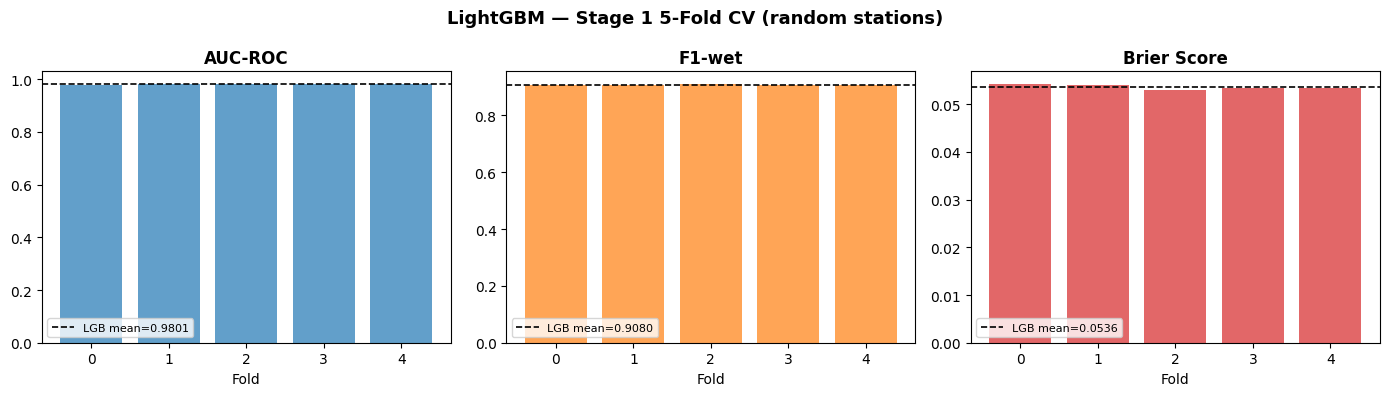

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics_plot = [
    ('auc',    'AUC-ROC',     'tab:blue'),
    ('f1_wet', 'F1-wet',      'tab:orange'),
    ('brier',  'Brier Score', 'tab:red'),
]

for ax, (col, title, color) in zip(axes, metrics_plot):
    vals = results_df[col]
    ax.bar(vals.index, vals, color=color, alpha=0.7)
    ax.axhline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'LGB mean={vals.mean():.4f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_xticks(range(K_FOLDS))
    ax.legend(fontsize=8)

fig.suptitle('LightGBM — Stage 1 5-Fold CV (random stations)', fontsize=13, fontweight='bold')
fig.tight_layout()

out_dir = Path('outputs')
out_dir.mkdir(exist_ok=True)
plt.savefig(out_dir / 'lgbm_stage1_cv5.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Feature Importance (last fold)

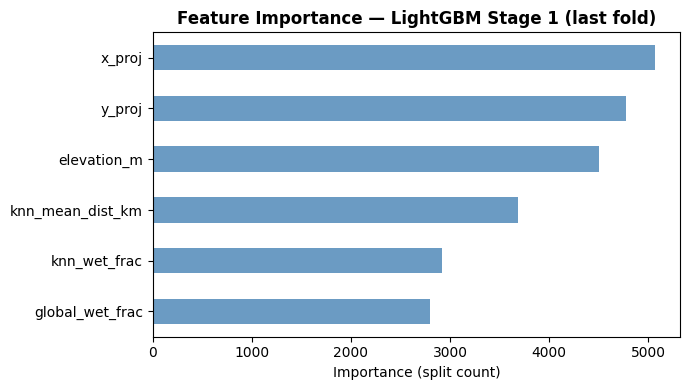

In [12]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Feature Importance — LightGBM Stage 1 (last fold)', fontweight='bold')
ax.set_xlabel('Importance (split count)')
fig.tight_layout()
plt.savefig(out_dir / 'lgbm_stage1_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Train Final Model on All Data

No held-out fold — train on every station and date.

## 13b. Load Saved Model (skip retraining)

If the model is already saved, run this instead of section 13.

In [13]:
import joblib
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from thesis.datasets.protocols import PredictionGrid

MODEL_PATH = Path('results/grk/lgbm_stage1_final.joblib')
final_model = joblib.load(MODEL_PATH)

print(f'Model loaded: {MODEL_PATH}')
print(f'  num_trees: {final_model.booster_.num_trees()}')

FileNotFoundError: [Errno 2] No such file or directory: 'results/grk/lgbm_stage1_final.joblib'

In [15]:
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from thesis.datasets.protocols import PredictionGrid

OUT_DIR = Path('results/lgbm/stage_1/')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Recompute features on ALL stations (no fold split)
station_meta_all = (
    all_proc
    .drop_duplicates('station_id')[['station_id', 'x_proj', 'y_proj', 'elevation_m']]
    .reset_index(drop=True)
)
station_xy_all = station_meta_all[['x_proj', 'y_proj']].values

gwf_all = (
    all_proc.groupby('date')['rain_indicator']
    .mean().rename('global_wet_frac').reset_index()
)

pivot_all = (
    all_proc[['date', 'station_id', 'rain_indicator']]
    .pivot_table(index='date', columns='station_id', values='rain_indicator', aggfunc='first')
)

tree_all = BallTree(station_xy_all, metric='euclidean')
tr_d, tr_i = tree_all.query(station_xy_all, k=K_NEIGHBORS + 1)

n_st = len(station_meta_all)
wet_mat_all = np.zeros((n_st, len(pivot_all)), dtype=np.float32)
dist_km_all = np.zeros(n_st, dtype=np.float32)

for i in range(n_st):
    mask = tr_d[i] > 1.0
    nbr_ids = station_meta_all['station_id'].values[tr_i[i][mask]][:K_NEIGHBORS]
    valid = [s for s in nbr_ids if s in pivot_all.columns]
    if valid:
        wet_mat_all[i] = pivot_all[valid].mean(axis=1).values
    dist_km_all[i] = tr_d[i][mask][:K_NEIGHBORS].mean() / 1000

knn_wet_all = (
    pd.DataFrame(wet_mat_all.T, index=pivot_all.index, columns=station_meta_all['station_id'].values)
    .reset_index().melt(id_vars='date', var_name='station_id', value_name='knn_wet_frac')
)
dist_all_df = pd.DataFrame({'station_id': station_meta_all['station_id'].values, 'knn_mean_dist_km': dist_km_all})

df_final = (
    all_proc
    .merge(gwf_all,      on='date',                 how='left')
    .merge(knn_wet_all,  on=['date', 'station_id'], how='left')
    .merge(dist_all_df,  on='station_id',            how='left')
)

X_all = df_final[FEATURE_COLS].values.astype(np.float32)
y_all = df_final[TARGET_COL].values.astype(np.int32)
print(f'X_all: {X_all.shape}  NaN: {np.isnan(X_all).sum()}')

spw = (y_all == 0).sum() / (y_all == 1).sum()
final_model = LGBMClassifier(**LGB_PARAMS, scale_pos_weight=spw)
final_model.fit(X_all, y_all)

import joblib
MODEL_PATH = OUT_DIR / 'lgbm_stage1_final.joblib'
joblib.dump(final_model, MODEL_PATH)
print(f'Model saved: {MODEL_PATH}')

X_all: (45237660, 6)  NaN: 0
Model saved: results/lgbm/stage_1/lgbm_stage1_final.joblib


## 14. Precompute Grid KNN

Computed once, cached for any date prediction.

In [16]:
grid     = PredictionGrid.from_config(cfg, dem=registry.dem)
H, W     = grid.shape
gx_flat  = grid.coords_proj[:, 0]
gy_flat  = grid.coords_proj[:, 1]
elev_flat = grid.elevation_m.ravel()
print(f'Grid: {grid.n_cells():,} cells  {H}×{W}')

KNN_CACHE = OUT_DIR / 'lgbm_grid_knn_indices.npz'

if KNN_CACHE.exists():
    print(f'Loading cached KNN from {KNN_CACHE}...')
    npz = np.load(KNN_CACHE)
    grid_knn_idxs  = npz['idxs']
    grid_knn_dists = npz['dists']
else:
    print(f'Computing KNN for {grid.n_cells():,} grid cells...')
    tree_grid = BallTree(station_xy_all, metric='euclidean')
    dists_m, idxs = tree_grid.query(np.column_stack([gx_flat, gy_flat]), k=K_NEIGHBORS)
    grid_knn_idxs  = idxs.astype(np.int32)
    grid_knn_dists = (dists_m / 1000).astype(np.float32)
    np.savez_compressed(KNN_CACHE, idxs=grid_knn_idxs, dists=grid_knn_dists)
    print(f'Saved: {KNN_CACHE}')

grid_knn_mean_dist = grid_knn_dists.mean(axis=1).astype(np.float32)
station_ids_ordered = station_meta_all['station_id'].values
print('Grid KNN ready.')

Grid: 202,818 cells  462×439
Computing KNN for 202,818 grid cells...
Saved: results/lgbm/stage_1/lgbm_grid_knn_indices.npz
Grid KNN ready.


## 15. Prediction Function

In [17]:
def predict_grid(date_str: str) -> dict:
    date_str = str(date_str)
    if date_str not in pivot_all.index:
        raise ValueError(f'Date {date_str} not in data')

    obs_row     = pivot_all.loc[date_str]
    station_obs = obs_row.reindex(station_ids_ordered).fillna(0).values.astype(np.float32)
    gwf_val     = float(np.nanmean(station_obs))

    knn_obs          = station_obs[grid_knn_idxs]
    knn_wet_frac_grid = knn_obs.mean(axis=1)

    X_grid = np.column_stack([
        gx_flat,
        gy_flat,
        elev_flat,
        np.full(len(gx_flat), gwf_val, np.float32),
        knn_wet_frac_grid,
        grid_knn_mean_dist,
    ]).astype(np.float32)

    p_wet_flat = final_model.predict_proba(X_grid)[:, 1]
    p_wet      = p_wet_flat.reshape(H, W)
    wet_grid   = p_wet > THRESHOLD

    day_df  = all_proc[all_proc['date'].astype(str) == date_str]
    n_wet   = int(day_df['rain_indicator'].sum())
    n_tot   = len(day_df)
    print(f'{date_str}: {n_tot} stations, {n_wet} wet ({n_wet/n_tot:.1%}) | grid wet: {wet_grid.mean():.1%}')

    return {
        'p_wet':    p_wet,
        'wet_grid': wet_grid,
        'stations': {
            'x':         day_df['x_proj'].values,
            'y':         day_df['y_proj'].values,
            'indicator': day_df['rain_indicator'].values,
        },
        'gwf': gwf_val,
    }

print('predict_grid() ready.')

predict_grid() ready.


## 16. Visualization Function

In [18]:
def plot_prediction(date_str: str, result: dict, zoom_radius_km: float = 70, save: bool = True) -> None:
    p_wet    = result['p_wet']
    wet_grid = result['wet_grid']
    st       = result['stations']

    gx_2d = gx_flat.reshape(H, W)
    gy_2d = gy_flat.reshape(H, W)
    ext   = [gx_2d[0,0]/1e3, gx_2d[0,-1]/1e3, gy_2d[0,0]/1e3, gy_2d[-1,0]/1e3]

    dist_to_thr = np.abs(p_wet - THRESHOLD)
    margin = 60
    dist_to_thr[:margin, :] = 999; dist_to_thr[-margin:, :] = 999
    dist_to_thr[:, :margin] = 999; dist_to_thr[:, -margin:] = 999
    row_t, col_t = np.unravel_index(np.argmin(dist_to_thr), dist_to_thr.shape)
    cx, cy = gx_2d[row_t, col_t], gy_2d[row_t, col_t]

    zoom_m  = zoom_radius_km * 1e3
    x_lo, x_hi = cx - zoom_m, cx + zoom_m
    y_lo, y_hi = cy - zoom_m, cy + zoom_m
    zoom_ext = [x_lo/1e3, x_hi/1e3, y_lo/1e3, y_hi/1e3]

    col_lo = max(0, np.searchsorted(gx_2d[0, :], x_lo) - 1)
    col_hi = min(W, np.searchsorted(gx_2d[0, :], x_hi) + 1)
    row_lo = max(0, np.searchsorted(gy_2d[:, 0], y_lo) - 1)
    row_hi = min(H, np.searchsorted(gy_2d[:, 0], y_hi) + 1)

    in_zoom = ((st['x'] >= x_lo) & (st['x'] <= x_hi) &
               (st['y'] >= y_lo) & (st['y'] <= y_hi))
    n_wet_st = int(st['indicator'].sum())
    n_tot_st = len(st['indicator'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 7.5))
    fig.subplots_adjust(bottom=0.22)

    # Panel 1: full domain
    ax = axes[0]
    im = ax.imshow(p_wet, cmap='RdYlBu', vmin=0, vmax=1, origin='lower', extent=ext)
    plt.colorbar(im, ax=ax, label='P(wet)', shrink=0.8)
    rect = plt.Rectangle((x_lo/1e3, y_lo/1e3), 2*zoom_m/1e3, 2*zoom_m/1e3,
                          lw=2, edgecolor='black', facecolor='none', ls='--')
    ax.add_patch(rect)
    ax.scatter(st['x']/1e3, st['y']/1e3,
               c=np.where(st['indicator']==1, 'steelblue', 'white'),
               edgecolors='black', linewidths=0.3, s=4, zorder=5)
    ax.set_title(f'P(wet) — full domain\n{date_str}  |  {n_wet_st}/{n_tot_st} wet  |  gwf={result["gwf"]:.2f}')
    ax.set_xlabel('Easting (km, EPSG:3035)')
    ax.set_ylabel('Northing (km, EPSG:3035)')

    # Panel 2: zoomed P(wet)
    ax = axes[1]
    p_zoom = p_wet[row_lo:row_hi, col_lo:col_hi]
    ax.imshow(p_zoom, cmap='RdYlBu', vmin=0, vmax=1, origin='lower', extent=zoom_ext, alpha=0.85)
    ax.contour(np.linspace(zoom_ext[0], zoom_ext[1], p_zoom.shape[1]),
               np.linspace(zoom_ext[2], zoom_ext[3], p_zoom.shape[0]),
               p_zoom, levels=[THRESHOLD], colors=['#c0392b'], linewidths=1.5, linestyles='--')
    ax.plot(cx/1e3, cy/1e3, 'rx', markersize=12, markeredgewidth=3, zorder=10)
    wet_z = st['indicator'][in_zoom] == 1
    if wet_z.sum():
        ax.scatter(st['x'][in_zoom][wet_z]/1e3, st['y'][in_zoom][wet_z]/1e3,
                   c='steelblue', s=35, edgecolors='black', linewidths=0.5, zorder=8)
    if (~wet_z).sum():
        ax.scatter(st['x'][in_zoom][~wet_z]/1e3, st['y'][in_zoom][~wet_z]/1e3,
                   c='#f0f0f0', s=35, edgecolors='black', linewidths=0.5, zorder=8)
    ax.set_title(f'Zoomed: P(wet) + stations\nthreshold = {THRESHOLD}  |  red ✕ = boundary point')
    ax.set_xlim(zoom_ext[0], zoom_ext[1]); ax.set_ylim(zoom_ext[2], zoom_ext[3])
    ax.set_xlabel('Easting (km)'); ax.set_aspect('equal')
    ax.legend(handles=[Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
                               markeredgecolor='black', markersize=7, label='Wet station'),
                        Line2D([0],[0], marker='o', color='w', markerfacecolor='#f0f0f0',
                               markeredgecolor='black', markersize=7, label='Dry station')],
              loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=9)

    # Panel 3: binary wet/dry
    ax = axes[2]
    wet_zoom = wet_grid[row_lo:row_hi, col_lo:col_hi].astype(float)
    ax.imshow(wet_zoom, cmap=ListedColormap(['#f5f5f5', 'steelblue']), vmin=0, vmax=1,
              origin='lower', extent=zoom_ext)
    ax.contour(np.linspace(zoom_ext[0], zoom_ext[1], wet_zoom.shape[1]),
               np.linspace(zoom_ext[2], zoom_ext[3], wet_zoom.shape[0]),
               p_wet[row_lo:row_hi, col_lo:col_hi],
               levels=[THRESHOLD], colors=['#c0392b'], linewidths=1.5, linestyles='--')
    if wet_z.sum():
        ax.scatter(st['x'][in_zoom][wet_z]/1e3, st['y'][in_zoom][wet_z]/1e3,
                   c='steelblue', s=25, edgecolors='black', linewidths=0.5, zorder=8, alpha=0.8)
    if (~wet_z).sum():
        ax.scatter(st['x'][in_zoom][~wet_z]/1e3, st['y'][in_zoom][~wet_z]/1e3,
                   c='white', s=25, edgecolors='black', linewidths=0.5, zorder=8, alpha=0.8)
    ax.legend(handles=[mpatches.Patch(facecolor='steelblue', label=f'Wet (P > {THRESHOLD})'),
                        mpatches.Patch(facecolor='#f5f5f5', edgecolor='gray', label=f'Dry (P ≤ {THRESHOLD})'),
                        Line2D([0],[0], color='#c0392b', ls='--', lw=1.5, label=f'P = {THRESHOLD} contour')],
              loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=9)
    ax.set_title(f'Binary wet/dry (P > {THRESHOLD})\nGrid wet: {wet_grid.mean():.1%}')
    ax.set_xlim(zoom_ext[0], zoom_ext[1]); ax.set_ylim(zoom_ext[2], zoom_ext[3])
    ax.set_xlabel('Easting (km)'); ax.set_aspect('equal')

    fig.suptitle(f'LightGBM Stage 1 Classifier — {date_str}', fontsize=14, fontweight='bold', y=1.01)
    fig.tight_layout()

    if save:
        img_dir = Path('images'); img_dir.mkdir(exist_ok=True)
        fname = img_dir / f'lgbm_stage1_{date_str}.png'
        fig.savefig(fname, dpi=200, bbox_inches='tight', facecolor='white')
        print(f'Saved: {fname}')
    plt.show()

print('plot_prediction() ready.')

plot_prediction() ready.


## 17. Run — change date here

Pick any date and run.

2013-11-24: 1966 stations, 931 wet (47.4%) | grid wet: 43.9%
Saved: images/lgbm_stage1_2013-11-24.png


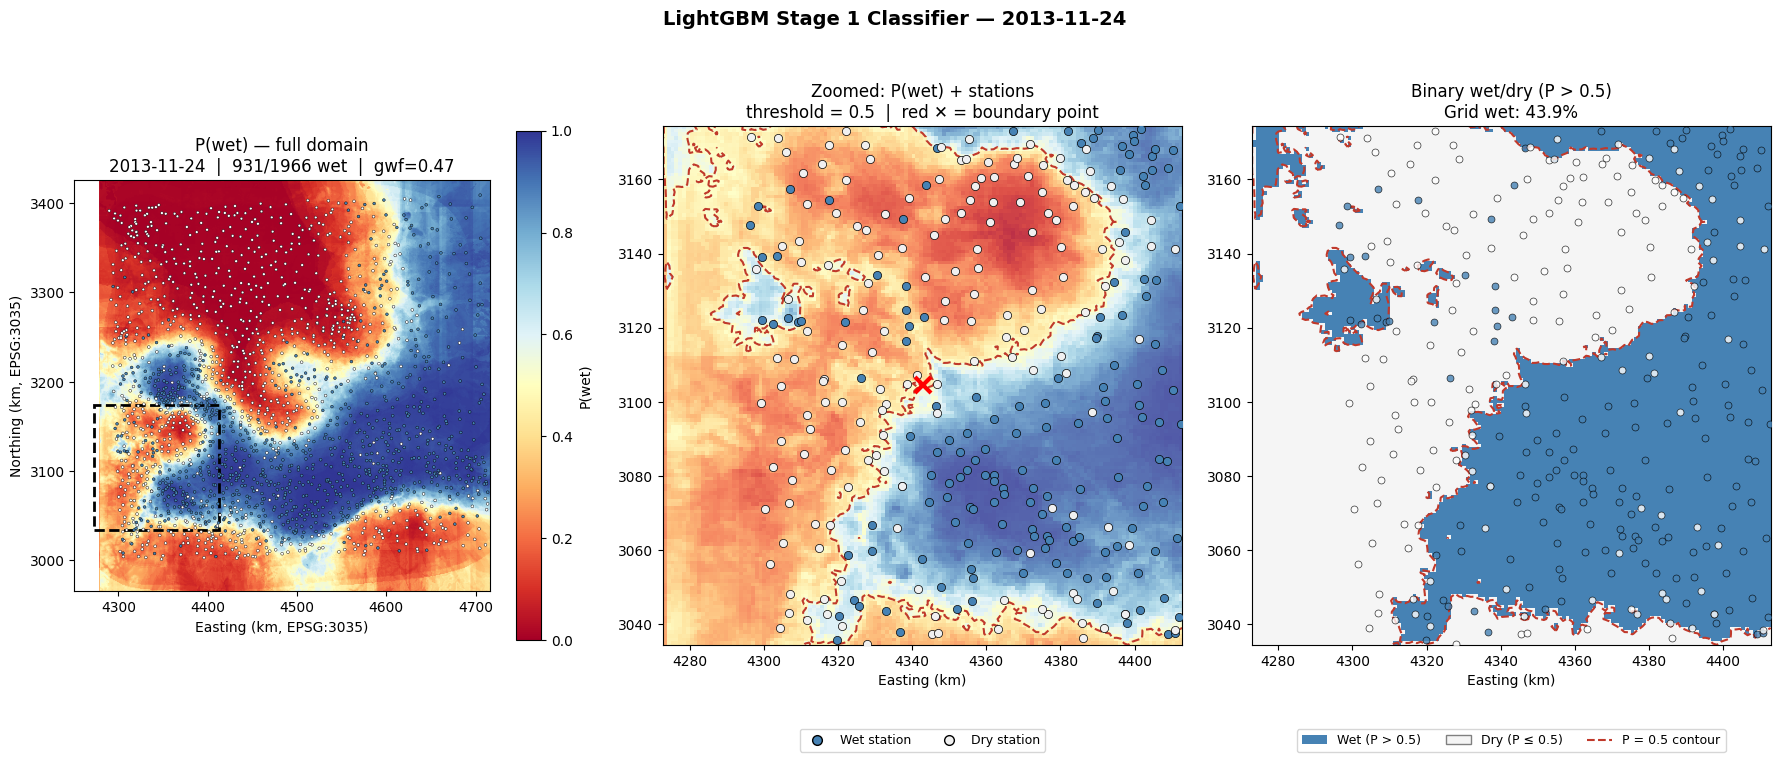

In [19]:
DATE = '2013-11-24'   # ← change date here

result = predict_grid(DATE)
plot_prediction(DATE, result, zoom_radius_km=70)

2013-11-24: 1966 stations, 931 wet (47.4%) | grid wet: 43.9%
Saved: images/lgbm_stage1_2013-11-24.png


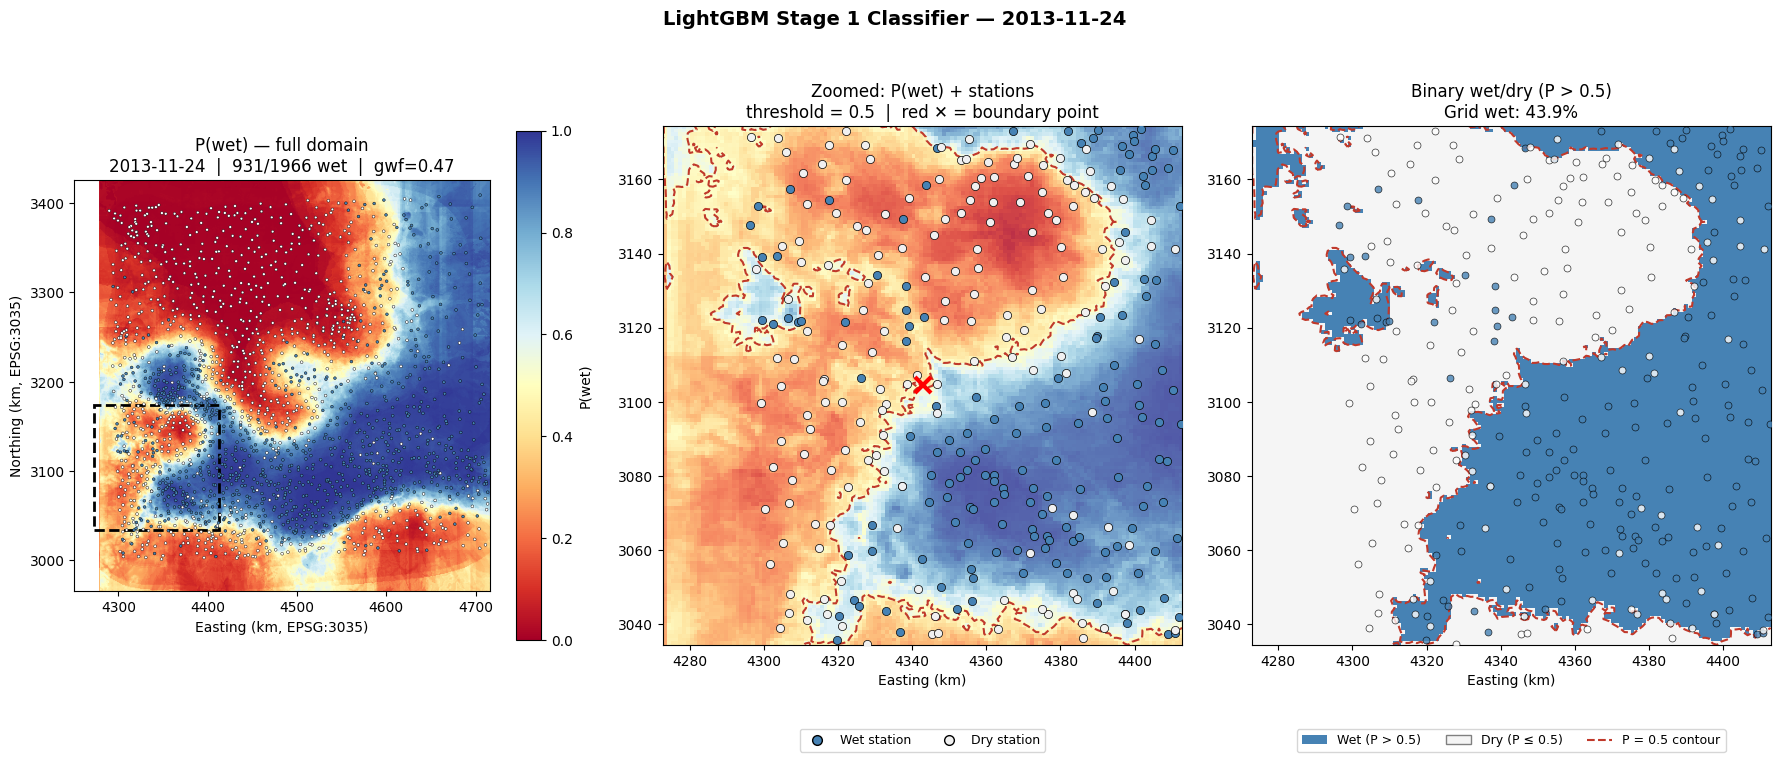

2013-02-01: 1966 stations, 1966 wet (100.0%) | grid wet: 100.0%
Saved: images/lgbm_stage1_2013-02-01.png


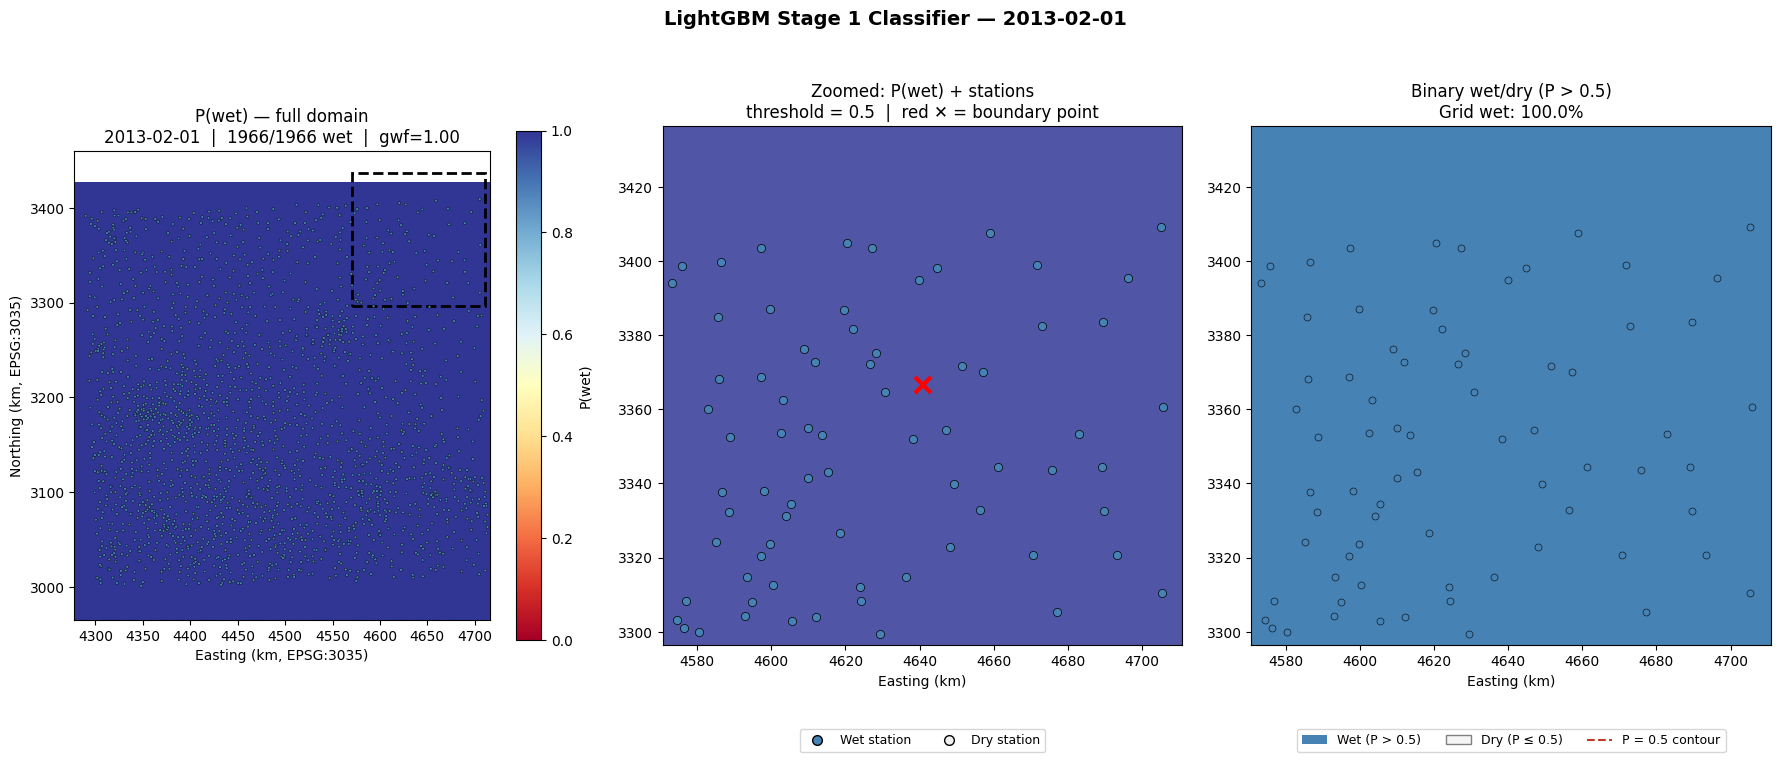

2001-07-15: 1966 stations, 1908 wet (97.0%) | grid wet: 96.9%
Saved: images/lgbm_stage1_2001-07-15.png


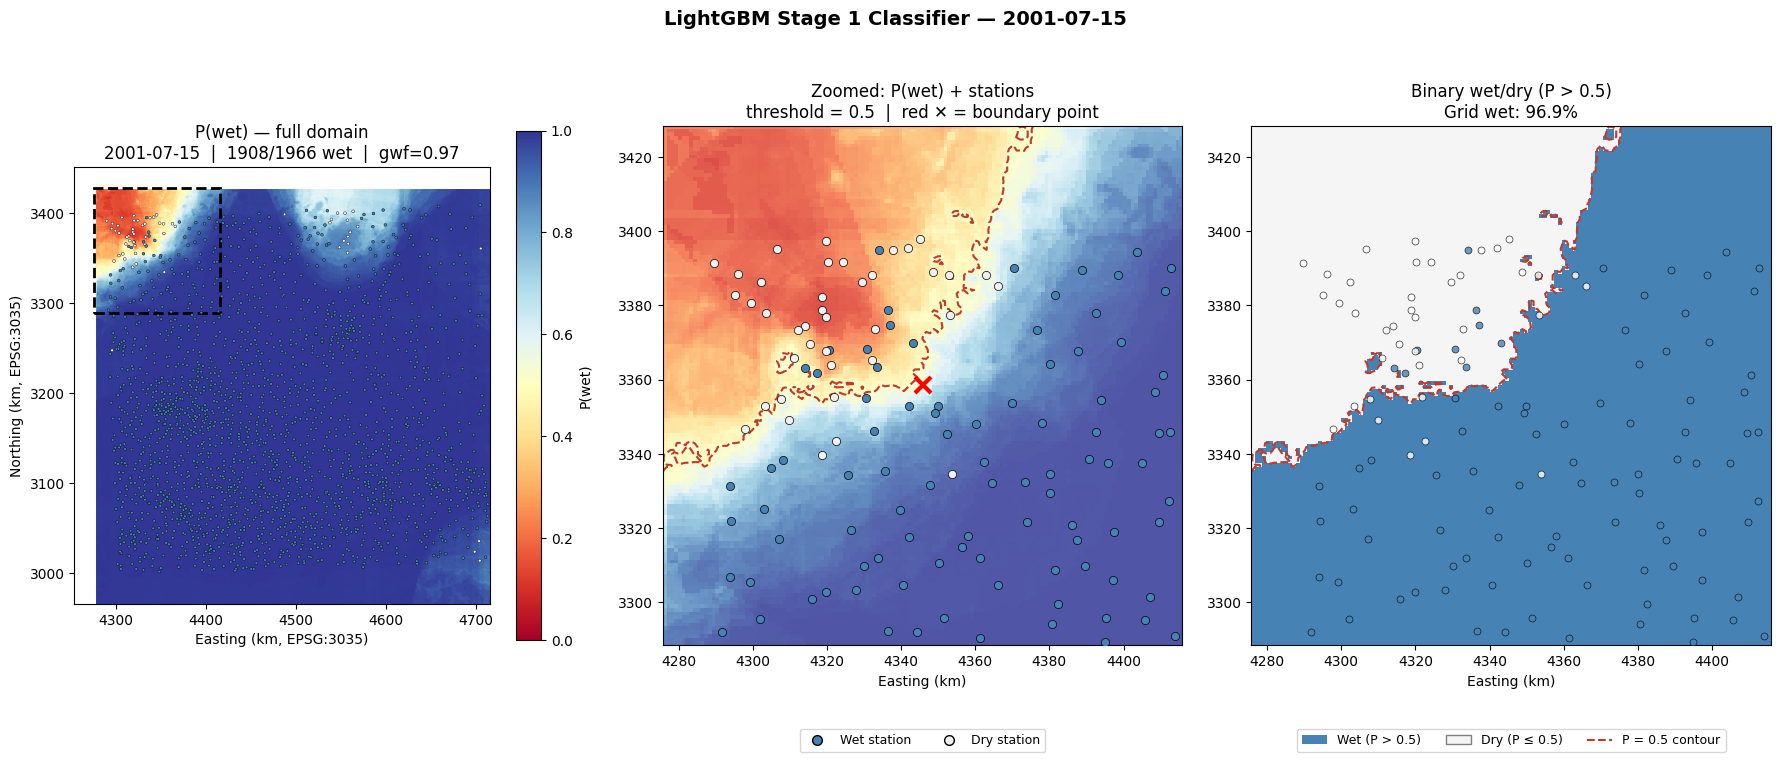

In [20]:
# Multiple dates at once
dates = ['2013-11-24', '2013-02-01', '2001-07-15']

for d in dates:
    r = predict_grid(d)
    plot_prediction(d, r, zoom_radius_km=70)